# ML4Sci GSoC 2026 — Common Test I: Multi-Class Gravitational Lens Classification
**Author:** Parv Patel | IIT Palakkad  

**Dataset structure:**
```
dataset/
  train/
    no/       → class 0  (no substructure)
    sphere/   → class 1  (subhalo / sphere substructure)
    vort/     → class 2  (vortex substructure)
  val/
    no/ | sphere/ | vort/
```
**Primary Metric:** ROC-AUC (One-vs-Rest, macro-averaged)

## Strategy

**Model choice: EfficientNet-B3 with transfer learning**

Lensing substructure (dark matter clumps, vortices) manifests as subtle multi-scale distortions in Einstein rings. EfficientNet-B3's compound scaling—depth, width, and resolution scaled simultaneously—makes it uniquely suited for capturing these at every spatial scale.

The transfer learning intuition directly mirrors deepfake detection: just as a deepfake detector learns to spot subtle spatial artifacts introduced by a generative model, our classifier learns to detect subtle physical distortions introduced by dark matter substructure.

| Decision | Reasoning |
|---|---|
| EfficientNet-B3 backbone | Best accuracy/compute tradeoff for fine-grained spatial classification |
| Rotational augmentation (0/90/180/270°) | Lensing images are rotationally symmetric — physically motivated, not generic |
| Label smoothing = 0.1 | Substructure class boundaries are soft; prevents overconfident predictions |
| WeightedRandomSampler | Class-balanced training without discarding samples |
| Differential LR (backbone 10× lower) | Preserves ImageNet features; prevents catastrophic forgetting |
| Cosine Annealing WarmRestarts | Escapes local minima during fine-tuning |
| Mixed precision (AMP) | ~2× GPU speedup with no accuracy loss |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

import warnings; warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
CONFIG = {
    'data_dir'     : '/kaggle/input/datasets/parvptl/gsoc-2026/dataset',         # ← UPDATE to your unzipped root
    'class_names'  : ['no', 'sphere', 'vort'],
    'display_names': ['No Substructure', 'Sphere/Subhalo', 'Vortex'],
    'img_size'     : 224,
    'batch_size'   : 32,
    'num_classes'  : 3,
    'epochs'       : 30,
    'lr'           : 3e-4,
    'weight_decay' : 1e-4,
    'val_split'    : 0.15,  # carved from train/
    'num_workers'  : 2,     # set 0 on Windows if errors occur
    'patience'     : 7,
    'save_path'    : 'best_model.pth',
}

## 1. Dataset

In [3]:
class LensDataset(Dataset):
    """
    Handles .npy lensing arrays (primary) and .png/.jpg fallback.
    .npy can be (H,W), (H,W,C), or (C,H,W) — all shapes handled.
    """
    MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __init__(self, file_paths, labels, img_size=224, augment=False, pil_transform=None):
        self.file_paths    = file_paths
        self.labels        = labels
        self.img_size      = img_size
        self.augment       = augment
        self.pil_transform = pil_transform   # used only for image files

    def __len__(self):
        return len(self.file_paths)

    def _npy_to_tensor(self, path):
        arr = np.load(path).astype(np.float32)
        arr = np.clip(arr, 0.0, 1.0)          # dataset is min-max; clamp for safety

        # Normalise shape → (3, H, W)
        if arr.ndim == 2:                      # (H, W)
            arr = np.stack([arr]*3, axis=0)
        elif arr.ndim == 3:
            if arr.shape[0] in (1, 3):         # already (C, H, W)
                arr = np.repeat(arr, 3, 0) if arr.shape[0]==1 else arr
            else:                              # (H, W, C)
                arr = arr.transpose(2,0,1)
                if arr.shape[0] == 1:
                    arr = np.repeat(arr, 3, 0)

        t = torch.from_numpy(arr)
        t = transforms.functional.resize(
            t, [self.img_size, self.img_size],
            interpolation=transforms.InterpolationMode.BILINEAR, antialias=True
        )

        # Augmentations (train only) — all physically motivated for lensing
        if self.augment:
            if torch.rand(1) > 0.5: t = transforms.functional.hflip(t)
            if torch.rand(1) > 0.5: t = transforms.functional.vflip(t)
            # 0/90/180/270° only — avoids edge interpolation artifacts
            k = torch.randint(0, 4, (1,)).item()
            t = torch.rot90(t, k, dims=[1, 2])

        # Normalize to ImageNet stats (proven to work for astronomy images)
        t = (t - self.MEAN) / self.STD
        return t

    def __getitem__(self, idx):
        path  = self.file_paths[idx]
        label = self.labels[idx]
        ext   = Path(path).suffix.lower()

        if ext == '.npy':
            img = self._npy_to_tensor(path)
        else:
            from PIL import Image
            img = Image.open(path).convert('RGB')
            if self.pil_transform:
                img = self.pil_transform(img)

        return img, label


def collect_files(split_dir, class_names):
    fps, labs = [], []
    for i, cls in enumerate(class_names):
        d = Path(split_dir) / cls
        if not d.exists():
            print(f'  WARNING: {d} not found — skipping')
            continue
        found = (list(d.rglob('*.npy')) + list(d.rglob('*.png')) +
                 list(d.rglob('*.jpg')) + list(d.rglob('*.jpeg')))
        fps.extend([str(f) for f in found])
        labs.extend([i] * len(found))
        print(f'  {cls:>10}: {len(found):>6} samples')
    return fps, labs

In [4]:
data_root = Path(CONFIG['data_dir'])

print('Train set:')
all_tr_fps, all_tr_labs = collect_files(data_root / 'train', CONFIG['class_names'])
print(f'  → Total: {len(all_tr_fps)}\n')

print('Val set:')
val_fps, val_labs = collect_files(data_root / 'val', CONFIG['class_names'])
print(f'  → Total: {len(val_fps)}')

# Detect file format
is_npy = Path(all_tr_fps[0]).suffix.lower() == '.npy'
print(f'\nFile format: {".npy" if is_npy else "image"}')

Train set:
          no:  10000 samples
      sphere:  10000 samples
        vort:  10000 samples
  → Total: 30000

Val set:
          no:   2500 samples
      sphere:   2500 samples
        vort:   2500 samples
  → Total: 7500

File format: .npy


In [5]:
# Carve a small split from train/ for early stopping only
tr_fps, split_fps, tr_labs, split_labs = train_test_split(
    all_tr_fps, all_tr_labs,
    test_size=CONFIG['val_split'],
    stratify=all_tr_labs, random_state=SEED
)
print(f'Splits → Train: {len(tr_fps)} | Split (early stop): {len(split_fps)} | Val: {len(val_fps)}')

# PIL transforms (only for image files, not npy)
mean, std = [0.485,0.456,0.406], [0.229,0.224,0.225]
tr_pil_tf = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(0.5), transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(180),
    transforms.ToTensor(), transforms.Normalize(mean, std),
]) if not is_npy else None

ev_pil_tf = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(), transforms.Normalize(mean, std),
]) if not is_npy else None

train_ds = LensDataset(tr_fps,    tr_labs,    CONFIG['img_size'], augment=is_npy, pil_transform=tr_pil_tf)
split_ds = LensDataset(split_fps, split_labs, CONFIG['img_size'], augment=False,  pil_transform=ev_pil_tf)
val_ds   = LensDataset(val_fps,   val_labs,   CONFIG['img_size'], augment=False,  pil_transform=ev_pil_tf)

# Balanced sampler
cc = np.bincount(tr_labs)
sw = [1.0 / cc[y] for y in tr_labs]
sampler = WeightedRandomSampler(sw, len(tr_labs), replacement=True)

nw = CONFIG['num_workers']
train_loader = DataLoader(train_ds, CONFIG['batch_size'], sampler=sampler,  num_workers=nw, pin_memory=True)
split_loader = DataLoader(split_ds, CONFIG['batch_size'], shuffle=False,    num_workers=nw, pin_memory=True)
val_loader   = DataLoader(val_ds,   CONFIG['batch_size'], shuffle=False,    num_workers=nw, pin_memory=True)

print(f'Class counts (train): { {c:int(n) for c,n in zip(CONFIG["class_names"], cc)} }')

Splits → Train: 25500 | Split (early stop): 4500 | Val: 7500
Class counts (train): {'no': 8500, 'sphere': 8500, 'vort': 8500}


## 2. EDA — Visualise One Sample Per Class

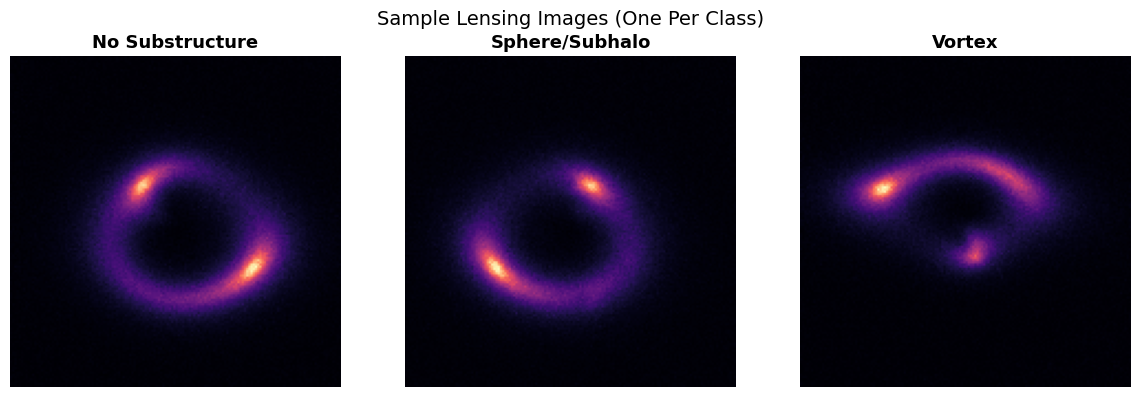

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (cls, disp) in enumerate(zip(CONFIG['class_names'], CONFIG['display_names'])):
    cls_dir = data_root / 'train' / cls
    sample  = sorted(cls_dir.glob('*.npy' if is_npy else '*.png'))[0]
    raw = np.load(sample).astype(np.float32) if is_npy else \
          np.array(__import__('PIL').Image.open(sample).convert('L'))
    # Show 2D slice
    if raw.ndim == 3:
        raw = raw[0] if raw.shape[0] <= 3 else raw[:,:,0]
    axes[i].imshow(raw, cmap='magma', origin='lower')
    axes[i].set_title(disp, fontsize=13, fontweight='bold')
    axes[i].axis('off')
fig.suptitle('Sample Lensing Images (One Per Class)', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

## 3. Model — EfficientNet-B3

In [7]:
def build_model(num_classes):
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
    # Freeze early low-level layers
    for name, p in model.named_parameters():
        if 'features.0' in name or 'features.1' in name:
            p.requires_grad = False
    # Custom 2-layer head
    in_f = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_f, 512), nn.GELU(), nn.BatchNorm1d(512),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )
    return model.to(DEVICE)

model    = build_model(CONFIG['num_classes'])
total    = sum(p.numel() for p in model.parameters())
trainable= sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params → Total: {total:,} | Trainable: {trainable:,} ({100*trainable/total:.1f}%)')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 154MB/s]


Params → Total: 11,485,739 | Trainable: 11,481,075 (100.0%)


## 4. Training

In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Differential LR: backbone 10× lower than new head
optimizer = optim.AdamW([
    {'params': [p for n,p in model.named_parameters() if 'classifier' not in n],
     'lr': CONFIG['lr'] * 0.1},
    {'params': model.classifier.parameters(), 'lr': CONFIG['lr']},
], weight_decay=CONFIG['weight_decay'])

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


def train_epoch(model, loader):
    model.train()
    tl, correct, total = 0.0, 0, 0
    for imgs, labs in loader:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            out = model(imgs); loss = criterion(out, labs)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        tl += loss.item()*imgs.size(0)
        correct += (out.argmax(1)==labs).sum().item()
        total   += imgs.size(0)
    return tl/total, correct/total


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    tl, correct, total = 0.0, 0, 0
    all_probs, all_labs = [], []
    for imgs, labs in loader:
        imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
        out = model(imgs); loss = criterion(out, labs)
        tl += loss.item()*imgs.size(0)
        correct += (out.argmax(1)==labs).sum().item()
        total   += imgs.size(0)
        all_probs.append(torch.softmax(out,1).cpu().numpy())
        all_labs.append(labs.cpu().numpy())
    return tl/total, correct/total, np.vstack(all_probs), np.concatenate(all_labs)

In [9]:
best_val_loss, patience_cnt = float('inf'), 0
history = {'tr_loss':[], 'va_loss':[], 'tr_acc':[], 'va_acc':[]}

print(f"{'Epoch':>6} | {'Tr Loss':>8} {'Tr Acc':>7} | {'Va Loss':>8} {'Va Acc':>7}")
print('─'*52)

for epoch in range(1, CONFIG['epochs']+1):
    tl, ta       = train_epoch(model, train_loader)
    vl, va, _,_  = eval_epoch(model, split_loader)
    scheduler.step()

    for k,v in zip(['tr_loss','va_loss','tr_acc','va_acc'],[tl,vl,ta,va]):
        history[k].append(v)

    flag = ''
    if vl < best_val_loss - 1e-4:
        best_val_loss = vl; patience_cnt = 0
        torch.save(model.state_dict(), CONFIG['save_path']); flag = ' ✓'
    else:
        patience_cnt += 1

    print(f"{epoch:>6} | {tl:>8.4f} {ta:>7.4f} | {vl:>8.4f} {va:>7.4f}{flag}")

    if patience_cnt >= CONFIG['patience']:
        print(f'\n⏹  Early stopping at epoch {epoch}.')
        break

 Epoch |  Tr Loss  Tr Acc |  Va Loss  Va Acc
────────────────────────────────────────────────────
     1 |   1.1660  0.3645 |   1.0810  0.4031 ✓
     2 |   1.0790  0.4103 |   1.0564  0.4378 ✓
     3 |   1.0415  0.4607 |   1.0037  0.4973 ✓
     4 |   0.9819  0.5253 |   0.9332  0.5709 ✓
     5 |   0.9260  0.5801 |   0.8925  0.6107 ✓
     6 |   0.8769  0.6173 |   0.8465  0.6462 ✓
     7 |   0.8488  0.6443 |   0.8251  0.6609 ✓
     8 |   0.8281  0.6600 |   0.8127  0.6704 ✓
     9 |   0.8230  0.6633 |   0.7985  0.6780 ✓
    10 |   0.8156  0.6689 |   0.7970  0.6807 ✓
    11 |   0.8059  0.6820 |   0.7818  0.6909 ✓
    12 |   0.7691  0.7090 |   0.7316  0.7302 ✓
    13 |   0.7358  0.7323 |   0.6967  0.7524 ✓
    14 |   0.7030  0.7583 |   0.6981  0.7540
    15 |   0.6736  0.7738 |   0.6801  0.7742 ✓
    16 |   0.6604  0.7853 |   0.6426  0.7971 ✓
    17 |   0.6399  0.7967 |   0.6379  0.8042 ✓
    18 |   0.6190  0.8108 |   0.6225  0.8078 ✓
    19 |   0.6025  0.8195 |   0.5977  0.8202 ✓
    20 |   

## 5. Val Set Evaluation

In [10]:
model.load_state_dict(torch.load(CONFIG['save_path'], map_location=DEVICE))
_, val_acc, val_probs, val_labels = eval_epoch(model, val_loader)

print(f'Val Accuracy: {val_acc:.4f}\n')
print(classification_report(
    val_labels, val_probs.argmax(1),
    target_names=CONFIG['display_names']
))

Val Accuracy: 0.8484

                 precision    recall  f1-score   support

No Substructure       0.81      0.95      0.88      2500
 Sphere/Subhalo       0.85      0.76      0.80      2500
         Vortex       0.89      0.84      0.86      2500

       accuracy                           0.85      7500
      macro avg       0.85      0.85      0.85      7500
   weighted avg       0.85      0.85      0.85      7500



## 6. ROC Curves & AUC — Primary Evaluation Metric

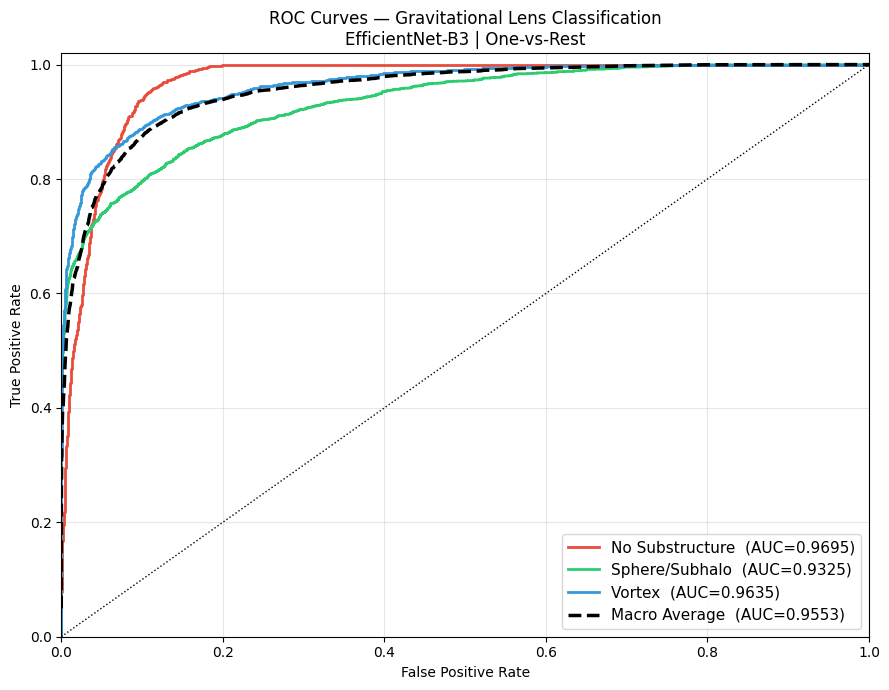


Per-class AUC:
         No Substructure: 0.9695
          Sphere/Subhalo: 0.9325
                  Vortex: 0.9635
           Macro Average: 0.9553


In [11]:
n  = CONFIG['num_classes']
lb = label_binarize(val_labels, classes=list(range(n)))
colors = ['#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(9,7))
aucs, fpr_list = [], []

for i in range(n):
    fpr, tpr, _ = roc_curve(lb[:,i], val_probs[:,i])
    a = auc(fpr, tpr); aucs.append(a); fpr_list.append(fpr)
    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f"{CONFIG['display_names'][i]}  (AUC={a:.4f})")

# Macro average
all_fpr  = np.unique(np.concatenate(fpr_list))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n):
    fpr, tpr, _ = roc_curve(lb[:,i], val_probs[:,i])
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= n
macro_auc = auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, 'k--', lw=2.5, label=f'Macro Average  (AUC={macro_auc:.4f})')
ax.plot([0,1],[0,1],'k:',lw=1)

ax.set(xlim=[0,1], ylim=[0,1.02],
       xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curves — Gravitational Lens Classification\nEfficientNet-B3 | One-vs-Rest')
ax.legend(loc='lower right', fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roc_curves.png', dpi=150); plt.show()

print('\nPer-class AUC:')
for name, a in zip(CONFIG['display_names'], aucs):
    print(f'  {name:>22}: {a:.4f}')
print(f'  {"Macro Average":>22}: {macro_auc:.4f}')

## 7. Training History

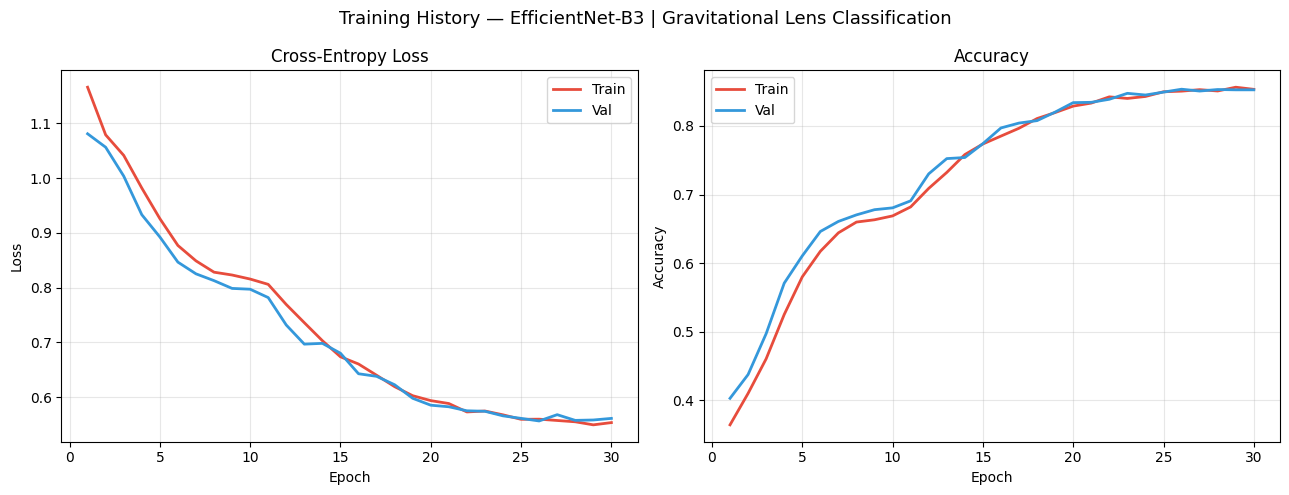


  Macro AUC  : 0.9553
  Val Acc    : 0.8484


In [12]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
ep = range(1, len(history['tr_loss'])+1)

axes[0].plot(ep, history['tr_loss'], label='Train', color='#e74c3c', lw=2)
axes[0].plot(ep, history['va_loss'], label='Val',   color='#3498db', lw=2)
axes[0].set(title='Cross-Entropy Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['tr_acc'], label='Train', color='#e74c3c', lw=2)
axes[1].plot(ep, history['va_acc'], label='Val',   color='#3498db', lw=2)
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle('Training History — EfficientNet-B3 | Gravitational Lens Classification', fontsize=13)
plt.tight_layout(); plt.savefig('training_history.png', dpi=150); plt.show()

print(f'\n{"="*52}')
print(f'  Macro AUC  : {macro_auc:.4f}')
print(f'  Val Acc    : {val_acc:.4f}')
print(f'{"="*52}')